Task-1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [3]:
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Matplotlib Version:", plt.matplotlib.__version__)
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

NumPy Version: 2.3.5
Pandas Version: 2.3.3
Matplotlib Version: 3.10.6
PyTorch Version: 2.11.0
Torchvision Version: 0.26.0


In [4]:
print("MPS Available (Mac GPU):", torch.backends.mps.is_available())

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU ")
else:
    device = torch.device("cpu")
    print("Running on CPU")

print("Selected Device:", device)

# This system uses Apple M2 chip, which does not support CUDA.
# PyTorch uses MPS (Metal Performance Shaders) for GPU acceleration.
# GPU (MPS/CUDA) is faster than CPU because it performs parallel computations.
# On GPU, training can be significantly faster and allows larger batch sizes.

MPS Available (Mac GPU): True
Using Apple MPS GPU
Selected Device: mps


In [5]:
# Reproducibility

torch.manual_seed(42) # torch.manual_seed → controls model weights and operations
np.random.seed(42) # numpy seed → controls NumPy randomness
random.seed(42) # random.seed → controls Python randomness

if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

In [16]:
from torchvision.datasets import MNIST, CIFAR10

mnist_train = MNIST(root="./data", train=True, download=True)
mnist_test = MNIST(root="./data", train=False, download=True)

cifar_train = CIFAR10(root="./data", train=True, download=True)
cifar_test = CIFAR10(root="./data", train=False, download=True)

In [17]:
import numpy as np

# MNIST
x_train_m = mnist_train.data.numpy()
y_train_m = mnist_train.targets.numpy()

x_test_m = mnist_test.data.numpy()
y_test_m = mnist_test.targets.numpy()

# CIFAR-10
x_train_c = np.array(cifar_train.data)
y_train_c = np.array(cifar_train.targets)

x_test_c = np.array(cifar_test.data)
y_test_c = np.array(cifar_test.targets)

In [18]:
print("MNIST Train Shape:", x_train_m.shape)
print("MNIST Test Shape:", x_test_m.shape)

print("CIFAR Train Shape:", x_train_c.shape)
print("CIFAR Test Shape:", x_test_c.shape)

MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)


In [19]:
print("\nMNIST dtype:", x_train_m.dtype)
print("CIFAR dtype:", x_train_c.dtype)


MNIST dtype: uint8
CIFAR dtype: uint8


In [20]:
print("\nMNIST range:", x_train_m.min(), x_train_m.max())
print("CIFAR range:", x_train_c.min(), x_train_c.max())


MNIST range: 0 255
CIFAR range: 0 255


In [21]:
unique, counts = np.unique(y_train_m, return_counts=True)
print("MNIST Class Distribution:")
print(dict(zip(unique, counts)))  
#MNIST class distribution is approximately balanced
# each class has around 6000 samples

MNIST Class Distribution:
{np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}


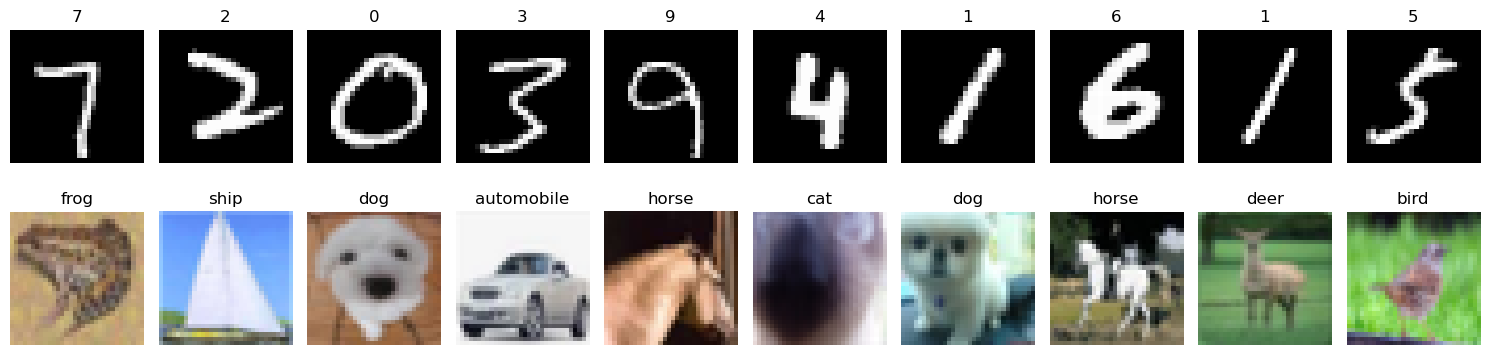

In [22]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# MNIST row
for i in range(10):
    idx = np.random.randint(len(x_train_m))
    axes[0, i].imshow(x_train_m[idx], cmap='gray')
    axes[0, i].set_title(str(y_train_m[idx]))
    axes[0, i].axis('off')

# CIFAR row
classes = cifar_train.classes
for i in range(10):
    idx = np.random.randint(len(x_train_c))
    axes[1, i].imshow(x_train_c[idx])
    axes[1, i].set_title(classes[y_train_c[idx]])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [31]:
def preprocessfunc(x, y, is_mnist=False):

    print("BEFORE PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    
    # Normalize to [0, 1]
    x = x.astype(np.float32) / 255.0  # Pixel values are scaled to the range [0,1] by dividing by 255.0.
     # This helps in faster convergence and stable training of neural networks.
    
    # Reshape MNIST (add channel dimension)
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
    
    # One-hot encode labels(Labels are converted into vectors of length 10, where the correct class index is 1 and others are 0.)
    y_onehot = np.eye(10)[y]
    
    print("\nAFTER PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    print("Label sample (one-hot):", y_onehot[0])
    
    return x, y_onehot

In [32]:
x_train_m_p, y_train_m_p = preprocessfunc(x_train_m, y_train_m, is_mnist=True)

BEFORE PREPROCESSING
Shape: (60000, 28, 28)
Dtype: uint8
Min/Max: 0 255
Sample values: [0 0 0 0 0 0 0 0 0 0]

AFTER PREPROCESSING
Shape: (60000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Label sample (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [33]:
x_train_c_p, y_train_c_p = preprocessfunc(x_train_c, y_train_c, is_mnist=False)

BEFORE PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: uint8
Min/Max: 0 255
Sample values: [59 62 63 43 46 45 50 48 43 68]

AFTER PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0.23137255 0.24313726 0.24705882 0.16862746 0.18039216 0.1764706
 0.19607843 0.1882353  0.16862746 0.26666668]
Label sample (one-hot): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
